# Modelo Actual de Clones de Codigo (Capa 1 Lexica)

Este notebook presenta el **modelo actual** para clasificacion de clones de codigo en Python.

La version actual integra una **primera capa lexica** compuesta por:
- tokenizacion y normalizacion de codigo,
- similitudes lexicas clasicas (TF-IDF y set-based),
- similitud tipo Baker basada en secuencias tokenizadas generalizadas.

Este flujo es la base para las siguientes capas del proyecto:
- AST,
- contexto,
- embeddings.


## 1) Configuracion e imports


In [41]:
# ------------------------------
# Imports del notebook
# - Utilidades de sistema y tipado
# - Librerias de analisis de datos
# - Herramientas de modelado y evaluacion
# ------------------------------
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Iterable
import io
import random
import re
import tokenize
import ast
import keyword

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import sparse
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.tree import DecisionTreeClassifier
from IPython.display import display


In [42]:
# Configuracion general
# Semilla para reproducibilidad global
SEED = 42

# Estrategia de balanceo del set de train:
# - none: no balancea
# - undersample: recorta clases mayoritarias
# - oversample: replica clases minoritarias
ESTRATEGIA_BALANCEO = 'undersample'  # none, undersample, oversample

# Longitud minima de match contiguo para features Baker
MIN_MATCH_LEN_BAKER = 3

random.seed(SEED)
np.random.seed(SEED)

# Resolucion de rutas: permite ejecutar notebook desde la raiz del repo
# o desde la carpeta DataBaseProject sin romper paths.
RUTA_BASE = Path.cwd()
if (RUTA_BASE / 'clone_pairs_dataset_metadata.csv').exists():
    RUTA_DATASET = RUTA_BASE
else:
    RUTA_DATASET = RUTA_BASE / 'DataBaseProject'

RUTA_METADATA = RUTA_DATASET / 'clone_pairs_dataset_metadata.csv'
RUTA_PARES = RUTA_DATASET / 'pares_clones'

print('RUTA_DATASET:', RUTA_DATASET)
print('RUTA_METADATA:', RUTA_METADATA)
print('RUTA_PARES:', RUTA_PARES)
print('ESTRATEGIA_BALANCEO:', ESTRATEGIA_BALANCEO)
print('MIN_MATCH_LEN_BAKER:', MIN_MATCH_LEN_BAKER)


RUTA_DATASET: c:\Users\estef\Downloads\code-clone-detector\DataBaseProject
RUTA_METADATA: c:\Users\estef\Downloads\code-clone-detector\DataBaseProject\clone_pairs_dataset_metadata.csv
RUTA_PARES: c:\Users\estef\Downloads\code-clone-detector\DataBaseProject\pares_clones
ESTRATEGIA_BALANCEO: undersample
MIN_MATCH_LEN_BAKER: 3


## 2) Dataset y reconstruccion de snippets


In [43]:
# Columnas esperadas del metadata original
COLUMNAS_METADATA = [
    'is_clone', 'clone_type', 'source_group', 'filename', 'file_path',
    'problem_id', 'snippet_index_a', 'snippet_index_b'
]

# Patrones para segmentar archivos con pares de snippets
PATRON_MARCADOR_LENGUAJE = re.compile(r'^\s*(python|java|javascript|c\+\+|cpp|ruby|go)\s*$', flags=re.IGNORECASE | re.MULTILINE)
PATRON_SEPARADOR_SNIPPETS = re.compile(r'\n\s*\n\s*\n+')
PATRON_ESPACIOS = re.compile(r'[ \t]+')
PATRON_SALTOS = re.compile(r'\n{3,}')


# Estructura para guardar indices de split sin perder referencia al dataframe
@dataclass
class ResultadoSplit:
    train_idx: pd.Index
    val_idx: pd.Index
    test_idx: pd.Index


def cargar_metadata(ruta_csv: Path) -> pd.DataFrame:
    # Carga plana del CSV
    return pd.read_csv(ruta_csv)


def limpiar_metadata(df: pd.DataFrame) -> pd.DataFrame:
    # Limpieza minima para asegurar integridad de los pares
    out = df.copy()
    out = out[COLUMNAS_METADATA].copy()
    out['is_clone'] = pd.to_numeric(out['is_clone'], errors='coerce')
    out['problem_id'] = pd.to_numeric(out['problem_id'], errors='coerce')
    out['snippet_index_a'] = pd.to_numeric(out['snippet_index_a'], errors='coerce')
    out['snippet_index_b'] = pd.to_numeric(out['snippet_index_b'], errors='coerce')
    out = out.dropna(subset=['is_clone', 'clone_type', 'file_path', 'problem_id', 'snippet_index_a', 'snippet_index_b']).copy()
    out['is_clone'] = out['is_clone'].astype(int)
    out['problem_id'] = out['problem_id'].astype(int)
    out['snippet_index_a'] = out['snippet_index_a'].astype(int)
    out['snippet_index_b'] = out['snippet_index_b'].astype(int)

    # El notebook modela solo pares que ya estan etiquetados como clon
    out = out[out['is_clone'] == 1].copy()
    return out


def separar_snippets(texto_archivo: str) -> list[str]:
    # Normaliza saltos para tener parsing consistente
    texto = texto_archivo.replace('\r\n', '\n').replace('\r', '\n').strip()
    if not texto:
        return []

    # 1) Intenta separar por bloques de lenguaje + separador de snippets
    bloques = [b.strip() for b in PATRON_MARCADOR_LENGUAJE.split(texto) if b.strip()]
    snippets = []
    for bloque in bloques:
        partes = [p.strip() for p in PATRON_SEPARADOR_SNIPPETS.split(bloque) if p.strip()]
        if len(partes) > 1:
            snippets.extend(partes)
        else:
            snippets.append(bloque)

    # 2) Fallback: si no detecta bien por lenguaje, separa solo por bloques vacios
    if len(snippets) < 2:
        fallback = [p.strip() for p in PATRON_SEPARADOR_SNIPPETS.split(texto) if p.strip()]
        if len(fallback) > len(snippets):
            snippets = fallback
    return snippets


def normalizar_ruta_relativa(ruta: str) -> Path:
    # Unifica separadores para compatibilidad entre sistemas
    return Path(str(ruta).replace('\\', '/'))


def reconstruir_pares(df_metadata: pd.DataFrame, ruta_dataset: Path) -> tuple[pd.DataFrame, pd.DataFrame, dict[str, Any]]:
    # Reconstruye code_a/code_b a partir de indices de snippet en cada archivo
    filas_ok = []
    filas_drop = []

    # Cache por archivo para no releer el mismo path muchas veces
    cache_snippets = {}

    for fila in df_metadata.itertuples(index=False):
        ruta_rel = normalizar_ruta_relativa(str(fila.file_path))
        ruta_abs = ruta_dataset / ruta_rel
        clave = str(ruta_rel).lower()

        if clave not in cache_snippets:
            if not ruta_abs.exists():
                cache_snippets[clave] = None
            else:
                texto = ruta_abs.read_text(encoding='utf-8', errors='replace')
                cache_snippets[clave] = separar_snippets(texto)

        snippets = cache_snippets[clave]
        if snippets is None:
            filas_drop.append({**fila._asdict(), 'drop_reason': 'file_not_found'})
            continue

        idx_a = int(fila.snippet_index_a)
        idx_b = int(fila.snippet_index_b)

        if idx_a < 0 or idx_b < 0:
            filas_drop.append({**fila._asdict(), 'drop_reason': 'negative_snippet_index'})
            continue

        if idx_a >= len(snippets) or idx_b >= len(snippets):
            filas_drop.append({**fila._asdict(), 'drop_reason': 'snippet_index_out_of_range'})
            continue

        filas_ok.append({
            **fila._asdict(),
            'resolved_path': str(ruta_abs),
            'snippet_count': len(snippets),
            'code_a': snippets[idx_a],
            'code_b': snippets[idx_b],
        })

    df_ok = pd.DataFrame(filas_ok)
    df_drop = pd.DataFrame(filas_drop)
    resumen = {
        'metadata_rows': int(len(df_metadata)),
        'reconstructed_rows': int(len(df_ok)),
        'dropped_rows': int(len(df_drop)),
    }
    return df_ok, df_drop, resumen


In [44]:
# Carga y reconstruccion del dataset usable para modelado
datos_metadata = cargar_metadata(RUTA_METADATA)
datos_metadata_limpios = limpiar_metadata(datos_metadata)
datos_reconstruidos, datos_descartados, resumen_reconstruccion = reconstruir_pares(datos_metadata_limpios, RUTA_DATASET)

print('Filas metadata:', len(datos_metadata))
print('Filas limpias (solo clones):', len(datos_metadata_limpios))
print('Resumen reconstruccion:', resumen_reconstruccion)

# Muestra motivos de descarte para inspeccionar calidad del dataset
if len(datos_descartados) > 0:
    print('Descartados por motivo:')
    print(datos_descartados['drop_reason'].value_counts())


Filas metadata: 8400
Filas limpias (solo clones): 8400
Resumen reconstruccion: {'metadata_rows': 8400, 'reconstructed_rows': 8400, 'dropped_rows': 0}


## 3) Preprocesamiento


In [45]:
def quitar_comentarios(codigo: str) -> str:
    # Elimina comentarios de Python preservando el resto de tokens
    if not codigo.strip():
        return codigo
    try:
        salida = []
        lector = io.StringIO(codigo).readline
        for tok in tokenize.generate_tokens(lector):
            if tok.type == tokenize.COMMENT:
                continue
            salida.append(tok)
        return tokenize.untokenize(salida)
    except (tokenize.TokenError, IndentationError):
        # Si hay codigo malformado, devuelve texto original para no perder muestra
        return codigo


def normalizar_espacios(codigo: str) -> str:
    # Estandariza espacios horizontales y compacta saltos excesivos
    lineas = []
    for linea in codigo.splitlines():
        compacta = PATRON_ESPACIOS.sub(' ', linea).rstrip()
        lineas.append(compacta)
    normalizado = '\n'.join(lineas).strip()
    normalizado = PATRON_SALTOS.sub('\n\n', normalizado)
    return normalizado


def preprocesar_codigo(codigo: str) -> str:
    # Pipeline de limpieza aplicado a cada snippet
    return normalizar_espacios(quitar_comentarios(codigo))


def tokenizar_python(codigo: str) -> list[str]:
    # Tokenizacion robusta para features lexicas
    if not codigo.strip():
        return []
    try:
        tokens = []
        lector = io.StringIO(codigo).readline
        excluir = {tokenize.ENCODING, tokenize.ENDMARKER, tokenize.NL, tokenize.NEWLINE, tokenize.INDENT, tokenize.DEDENT, tokenize.COMMENT}
        for tok in tokenize.generate_tokens(lector):
            if tok.type in excluir:
                continue
            t = tok.string.strip()
            if t:
                tokens.append(t)
        return tokens
    except (tokenize.TokenError, IndentationError):
        # Fallback por regex para no descartar muestra por errores de parseo
        return re.findall(r'[A-Za-z_]\w*|\d+|==|!=|<=|>=|[-+*/%=<>()[\]{}.,:;]', codigo)


def preparar_campos_par(df: pd.DataFrame) -> pd.DataFrame:
    # Prepara todas las columnas derivadas usadas por el modelo
    out = df.copy()
    code_a_clean = [preprocesar_codigo(x) for x in out['code_a'].astype(str)]
    code_b_clean = [preprocesar_codigo(x) for x in out['code_b'].astype(str)]
    tokens_a = [tokenizar_python(x) for x in code_a_clean]
    tokens_b = [tokenizar_python(x) for x in code_b_clean]

    out['code_a_clean'] = code_a_clean
    out['code_b_clean'] = code_b_clean
    out['tokens_a'] = tokens_a
    out['tokens_b'] = tokens_b
    out['token_text_a'] = [' '.join(t) for t in tokens_a]
    out['token_text_b'] = [' '.join(t) for t in tokens_b]
    return out


datos_preparados = preparar_campos_par(datos_reconstruidos)
print('Filas listas para modelado:', len(datos_preparados))


Filas listas para modelado: 8400


## 4) Capa lexica del modelo (TF-IDF + similitudes + Baker)


In [46]:
# ---- Parte A: similitudes lexicas clasicas ----


def similitud_jaccard(tokens_a: Iterable[str], tokens_b: Iterable[str]) -> float:
    # |A ? B| / |A ? B| con tokens unicos
    set_a = set(tokens_a); set_b = set(tokens_b)
    if not set_a and not set_b:
        return 1.0
    union = set_a | set_b
    if not union:
        return 0.0
    return float(len(set_a & set_b) / len(union))


def similitud_dice(tokens_a: Iterable[str], tokens_b: Iterable[str]) -> float:
    # 2|A ? B| / (|A| + |B|)
    set_a = set(tokens_a); set_b = set(tokens_b)
    if not set_a and not set_b:
        return 1.0
    denom = len(set_a) + len(set_b)
    if denom == 0:
        return 0.0
    return float(2.0 * len(set_a & set_b) / denom)


def ratio_overlap(tokens_a: Iterable[str], tokens_b: Iterable[str]) -> float:
    # |A ? B| / min(|A|, |B|)
    set_a = set(tokens_a); set_b = set(tokens_b)
    if not set_a and not set_b:
        return 1.0
    min_size = min(len(set_a), len(set_b))
    if min_size == 0:
        return 0.0
    return float(len(set_a & set_b) / min_size)


def ajustar_tfidf(df_train: pd.DataFrame) -> TfidfVectorizer:
    # Ajuste SOLO con train para evitar leakage
    corpus = pd.concat([df_train['token_text_a'], df_train['token_text_b']], axis=0)
    vector = TfidfVectorizer(tokenizer=str.split, preprocessor=None, token_pattern=None, lowercase=False, ngram_range=(1, 2), min_df=1)
    vector.fit(corpus)
    return vector


def coseno_fila_a_fila(mat_a: sparse.spmatrix, mat_b: sparse.spmatrix) -> np.ndarray:
    # Similitud coseno por fila sin expandir matrices densas
    producto = np.asarray(mat_a.multiply(mat_b).sum(axis=1)).ravel()
    norma_a = np.sqrt(np.asarray(mat_a.multiply(mat_a).sum(axis=1)).ravel())
    norma_b = np.sqrt(np.asarray(mat_b.multiply(mat_b).sum(axis=1)).ravel())
    denom = norma_a * norma_b
    denom[denom == 0.0] = 1e-12
    return producto / denom


def construir_features_lexicas_base(df: pd.DataFrame, vector: TfidfVectorizer) -> pd.DataFrame:
    # 1) Similitud por contenido textual tokenizado
    mat_a = vector.transform(df['token_text_a'])
    mat_b = vector.transform(df['token_text_b'])
    coseno = coseno_fila_a_fila(mat_a, mat_b)

    # 2) Rasgos de longitud/estructura superficial
    chars_a = df['code_a_clean'].str.len().astype(float)
    chars_b = df['code_b_clean'].str.len().astype(float)
    lineas_a = df['code_a_clean'].str.count('\n').astype(float) + 1.0
    lineas_b = df['code_b_clean'].str.count('\n').astype(float) + 1.0
    tokens_a = df['tokens_a'].apply(len).astype(float)
    tokens_b = df['tokens_b'].apply(len).astype(float)

    # 3) Similitudes por conjuntos de tokens
    jaccard = [similitud_jaccard(a, b) for a, b in zip(df['tokens_a'], df['tokens_b'])]
    dice = [similitud_dice(a, b) for a, b in zip(df['tokens_a'], df['tokens_b'])]
    overlap = [ratio_overlap(a, b) for a, b in zip(df['tokens_a'], df['tokens_b'])]

    return pd.DataFrame({
        'cosine_tfidf': coseno,
        'jaccard_tokens': jaccard,
        'dice_tokens': dice,
        'overlap_unique_tokens': overlap,
        'char_len_a': chars_a,
        'char_len_b': chars_b,
        'char_len_diff': (chars_a - chars_b).abs(),
        'line_count_a': lineas_a,
        'line_count_b': lineas_b,
        'line_count_diff': (lineas_a - lineas_b).abs(),
        'token_count_a': tokens_a,
        'token_count_b': tokens_b,
        'token_count_diff': (tokens_a - tokens_b).abs(),
    }, index=df.index)


# ---- Parte B: Baker integrado en la capa lexica ----


def baker_tokenizar_generalizar(codigo: str) -> list[str]:
    # Generaliza identificadores/literales para medir similitud estructural lexical
    if not codigo.strip():
        return []
    out = []
    try:
        lector = io.StringIO(codigo).readline
        for tok in tokenize.generate_tokens(lector):
            if tok.type in {tokenize.ENCODING, tokenize.ENDMARKER, tokenize.NL, tokenize.NEWLINE, tokenize.INDENT, tokenize.DEDENT, tokenize.COMMENT}:
                continue
            s = tok.string.strip()
            if not s:
                continue
            if tok.type == tokenize.NAME:
                out.append(s if keyword.iskeyword(s) else 'ID')
            elif tok.type == tokenize.NUMBER:
                out.append('NUM')
            elif tok.type == tokenize.STRING:
                out.append('STR')
            else:
                out.append(s)
    except (tokenize.TokenError, IndentationError):
        return []
    return out


def baker_suffix_array(seq: list[str]) -> list[int]:
    # Construye suffix array O(n log n) por doubling
    n = len(seq)
    if n <= 1:
        return list(range(n))
    uniq = {t: i for i, t in enumerate(sorted(set(seq)))}
    rank = [uniq[t] for t in seq]
    sa = list(range(n))
    tmp = [0] * n
    k = 1
    while True:
        sa.sort(key=lambda i: (rank[i], rank[i + k] if i + k < n else -1))
        clases = 0
        tmp[sa[0]] = 0
        for i in range(1, n):
            p, c = sa[i - 1], sa[i]
            kp = (rank[p], rank[p + k] if p + k < n else -1)
            kc = (rank[c], rank[c + k] if c + k < n else -1)
            if kp != kc:
                clases += 1
            tmp[c] = clases
        rank = tmp[:]
        if clases == n - 1:
            break
        k <<= 1
    return sa


def baker_lcp_array(seq: list[str], sa: list[int]) -> list[int]:
    # Kasai: LCP entre sufijos adyacentes del suffix array
    n = len(seq)
    if n == 0:
        return []
    rank = [0] * n
    for i, s in enumerate(sa):
        rank[s] = i
    lcp = [0] * n
    k = 0
    for i in range(n):
        ri = rank[i]
        if ri == 0:
            k = 0
            continue
        j = sa[ri - 1]
        while i + k < n and j + k < n and seq[i + k] == seq[j + k]:
            k += 1
        lcp[ri] = k
        if k > 0:
            k -= 1
    return lcp


def baker_features_par(codigo_a: str, codigo_b: str, min_match_len: int = 3) -> dict[str, float]:
    # Calcula similitud Baker para un par de snippets
    ta = baker_tokenizar_generalizar(codigo_a)
    tb = baker_tokenizar_generalizar(codigo_b)
    la, lb = len(ta), len(tb)

    # Si no hay tokens utiles, retorna vector nulo
    if la == 0 or lb == 0:
        return {
            'baker_similarity': 0.0,
            'baker_common_length': 0.0,
            'baker_longest_match': 0.0,
            'baker_num_matches': 0.0,
            'baker_coverage_a': 0.0,
            'baker_coverage_b': 0.0,
        }

    # Separadores sentinela para concatenar ambas secuencias sin cruces falsos
    sep1 = '__A_END__'
    sep2 = '__B_END__'
    while sep1 in ta or sep1 in tb:
        sep1 += '_X'
    while sep2 in ta or sep2 in tb or sep2 == sep1:
        sep2 += '_Y'

    concat = ta + [sep1] + tb + [sep2]
    sa = baker_suffix_array(concat)
    lcp = baker_lcp_array(concat, sa)

    def origen(idx: int) -> int:
        if idx < la:
            return 0
        if idx == la or idx == la + 1 + lb:
            return -1
        if la < idx < la + 1 + lb:
            return 1
        return -1

    # Candidatos de coincidencia comun de longitud >= min_match_len
    candidatos = []
    for i in range(1, len(sa)):
        common = lcp[i]
        if common < min_match_len:
            continue
        s1, s2 = sa[i - 1], sa[i]
        o1, o2 = origen(s1), origen(s2)
        if o1 == -1 or o2 == -1 or o1 == o2:
            continue

        if o1 == 0:
            a0 = s1
            b0 = s2 - (la + 1)
        else:
            a0 = s2
            b0 = s1 - (la + 1)

        if a0 < 0 or b0 < 0:
            continue
        common = min(common, la - a0, lb - b0)
        if common >= min_match_len:
            candidatos.append((a0, b0, common))

    # Seleccion greedy sin solapes para evitar doble conteo de cobertura
    candidatos = sorted(set(candidatos), key=lambda x: (-x[2], x[0], x[1]))
    cover_a = [False] * la
    cover_b = [False] * lb
    seleccion = []
    for a0, b0, ln in candidatos:
        ra = range(a0, a0 + ln)
        rb = range(b0, b0 + ln)
        if any(cover_a[i] for i in ra) or any(cover_b[j] for j in rb):
            continue
        seleccion.append((a0, b0, ln))
        for i in ra:
            cover_a[i] = True
        for j in rb:
            cover_b[j] = True

    common_len = float(sum(ln for _, _, ln in seleccion))
    longest = float(max((ln for _, _, ln in seleccion), default=0))
    nmatch = float(len(seleccion))
    cov_a = common_len / float(la) if la > 0 else 0.0
    cov_b = common_len / float(lb) if lb > 0 else 0.0
    sim = common_len / float(min(la, lb)) if min(la, lb) > 0 else 0.0

    return {
        'baker_similarity': sim,
        'baker_common_length': common_len,
        'baker_longest_match': longest,
        'baker_num_matches': nmatch,
        'baker_coverage_a': cov_a,
        'baker_coverage_b': cov_b,
    }


def construir_features_baker(df: pd.DataFrame, min_match_len: int = 3) -> pd.DataFrame:
    # Aplica Baker fila a fila
    rows = [
        baker_features_par(a, b, min_match_len=min_match_len)
        for a, b in zip(df['code_a_clean'], df['code_b_clean'])
    ]
    return pd.DataFrame(rows, index=df.index)


def construir_features_modelo(df: pd.DataFrame, vector: TfidfVectorizer, min_match_len: int = 3) -> pd.DataFrame:
    # Vector final de la capa lexica: clasico + Baker
    x_base = construir_features_lexicas_base(df, vector)
    x_baker = construir_features_baker(df, min_match_len=min_match_len)
    return pd.concat([x_base, x_baker], axis=1)


## 5) Capa estructural AST y vector final de features

En esta seccion se integra una capa estructural inspirada en el enfoque de recorrido de arbol usado en `analisis.py` y `arbol.py`.

- Se parsea cada snippet con `ast` de Python.
- Se recorre el arbol en profundidad para contar rasgos estructurales.
- Se construyen features por par para medir diferencias y similitud estructural.
- Estas features se concatenan con la capa lexica para el vector final del modelo.


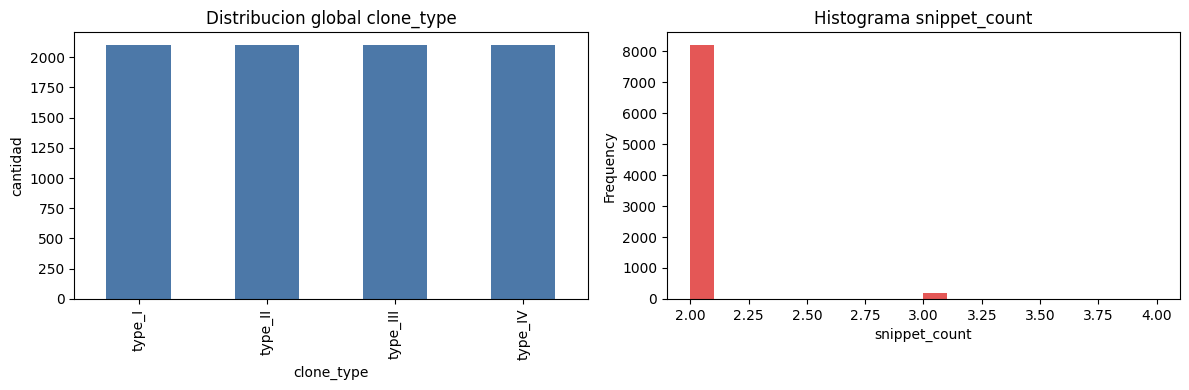

In [47]:
# ---- Capa estructural AST: extraccion por snippet y por par ----

# La idea sigue el estilo de analisis.py/arbol.py:
# 1) parsear codigo a AST,
# 2) recorrer nodo por nodo,
# 3) extraer metricas estructurales interpretables.

def _ast_walk_metrics(tree: ast.AST) -> dict[str, Any]:
    """Recorre el AST en profundidad y devuelve metricas estructurales del snippet."""
    total_nodes = 0
    max_depth = 0
    num_functions = 0
    num_loops = 0
    num_ifs = 0
    num_calls = 0
    num_imports = 0
    type_counts: dict[str, int] = {}

    def visit(node: ast.AST, depth: int) -> None:
        """Visitor recursivo: actualiza contadores y visita hijos."""
        nonlocal total_nodes, max_depth, num_functions, num_loops, num_ifs, num_calls, num_imports
        total_nodes += 1
        max_depth = max(max_depth, depth)

        # Conteo por tipo de nodo (histograma estructural).
        tname = type(node).__name__
        type_counts[tname] = type_counts.get(tname, 0) + 1

        # Conteos funcionales principales para caracterizar la forma del codigo.
        if isinstance(node, (ast.FunctionDef, ast.AsyncFunctionDef)):
            num_functions += 1
        if isinstance(node, (ast.For, ast.AsyncFor, ast.While)):
            num_loops += 1
        if isinstance(node, ast.If):
            num_ifs += 1
        if isinstance(node, ast.Call):
            num_calls += 1
        if isinstance(node, (ast.Import, ast.ImportFrom)):
            num_imports += 1

        for child in ast.iter_child_nodes(node):
            visit(child, depth + 1)

    visit(tree, 1)
    return {
        'ast_total_nodes': float(total_nodes),
        'ast_depth': float(max_depth),
        'ast_num_functions': float(num_functions),
        'ast_num_loops': float(num_loops),
        'ast_num_ifs': float(num_ifs),
        'ast_num_calls': float(num_calls),
        'ast_num_imports': float(num_imports),
        'ast_type_counts': type_counts,
    }


def extraer_features_ast_snippet(codigo: str) -> dict[str, Any]:
    """Extrae features AST de un snippet; si falla el parseo devuelve ceros."""
    codigo_ok = codigo if codigo.strip() else 'pass'
    try:
        tree = ast.parse(codigo_ok)
        return _ast_walk_metrics(tree)
    except SyntaxError:
        return {
            'ast_total_nodes': 0.0,
            'ast_depth': 0.0,
            'ast_num_functions': 0.0,
            'ast_num_loops': 0.0,
            'ast_num_ifs': 0.0,
            'ast_num_calls': 0.0,
            'ast_num_imports': 0.0,
            'ast_type_counts': {},
        }


def _jaccard_keys(d1: dict[str, int], d2: dict[str, int]) -> float:
    """Jaccard entre conjuntos de tipos de nodo presentes en ambos snippets."""
    k1, k2 = set(d1.keys()), set(d2.keys())
    if not k1 and not k2:
        return 1.0
    u = k1 | k2
    if not u:
        return 0.0
    return float(len(k1 & k2) / len(u))


def _weighted_overlap_counts(d1: dict[str, int], d2: dict[str, int]) -> float:
    """Solapamiento ponderado por frecuencia de cada tipo de nodo."""
    keys = set(d1.keys()) | set(d2.keys())
    if not keys:
        return 1.0
    inter = 0.0
    union = 0.0
    for k in keys:
        a = float(d1.get(k, 0))
        b = float(d2.get(k, 0))
        inter += min(a, b)
        union += max(a, b)
    if union == 0.0:
        return 0.0
    return inter / union


def construir_features_ast_par(df: pd.DataFrame) -> pd.DataFrame:
    """Construye features estructurales por par (code_a, code_b)."""
    rows = []
    for ca, cb in zip(df['code_a_clean'], df['code_b_clean']):
        fa = extraer_features_ast_snippet(ca)
        fb = extraer_features_ast_snippet(cb)

        n_a = fa['ast_total_nodes']
        n_b = fb['ast_total_nodes']
        d_a = fa['ast_depth']
        d_b = fb['ast_depth']
        f_a = fa['ast_num_functions']
        f_b = fb['ast_num_functions']
        l_a = fa['ast_num_loops']
        l_b = fb['ast_num_loops']
        i_a = fa['ast_num_ifs']
        i_b = fb['ast_num_ifs']
        c_a = fa['ast_num_calls']
        c_b = fb['ast_num_calls']
        imp_a = fa['ast_num_imports']
        imp_b = fb['ast_num_imports']

        # Similitudes de estructura global y de vocabulario de nodos.
        type_jaccard = _jaccard_keys(fa['ast_type_counts'], fb['ast_type_counts'])
        type_weighted = _weighted_overlap_counts(fa['ast_type_counts'], fb['ast_type_counts'])

        node_len_sim = (min(n_a, n_b) / max(n_a, n_b)) if max(n_a, n_b) > 0 else 1.0
        depth_sim = (min(d_a, d_b) / max(d_a, d_b)) if max(d_a, d_b) > 0 else 1.0
        structural_similarity = float(np.mean([node_len_sim, depth_sim, type_jaccard, type_weighted]))

        rows.append({
            'ast_nodes_a': n_a,
            'ast_nodes_b': n_b,
            'ast_nodes_diff': abs(n_a - n_b),
            'ast_depth_a': d_a,
            'ast_depth_b': d_b,
            'ast_depth_diff': abs(d_a - d_b),
            'ast_functions_diff': abs(f_a - f_b),
            'ast_loops_diff': abs(l_a - l_b),
            'ast_ifs_diff': abs(i_a - i_b),
            'ast_calls_diff': abs(c_a - c_b),
            'ast_imports_diff': abs(imp_a - imp_b),
            'ast_node_type_overlap': type_jaccard,
            'ast_node_type_weighted_overlap': type_weighted,
            'ast_structural_similarity': structural_similarity,
        })

    return pd.DataFrame(rows, index=df.index)


def construir_features_modelo_capa1(df: pd.DataFrame, vector: TfidfVectorizer, min_match_len: int = 3) -> pd.DataFrame:
    """Capa lexica del modelo: TF-IDF + similitudes clasicas + Baker."""
    x_base = construir_features_lexicas_base(df, vector)
    x_baker = construir_features_baker(df, min_match_len=min_match_len)
    return pd.concat([x_base, x_baker], axis=1)


def construir_features_modelo_capa1_ast(df: pd.DataFrame, vector: TfidfVectorizer, min_match_len: int = 3) -> pd.DataFrame:
    """Vector extendido: capa lexica + capa estructural AST."""
    x_lex = construir_features_modelo_capa1(df, vector, min_match_len=min_match_len)
    x_ast = construir_features_ast_par(df)
    return pd.concat([x_lex, x_ast], axis=1)


# Visualizacion rapida de distribucion
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
datos_preparados['clone_type'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='#4C78A8')
axes[0].set_title('Distribucion global clone_type')
axes[0].set_xlabel('clone_type')
axes[0].set_ylabel('cantidad')

datos_preparados['snippet_count'].plot(kind='hist', bins=20, ax=axes[1], color='#E45756')
axes[1].set_title('Histograma snippet_count')
axes[1].set_xlabel('snippet_count')
plt.tight_layout()
plt.show()


## 6) Split por `problem_id`


Estadisticas split del modelo:
{'split': 'test', 'rows': 1260, 'unique_groups': 315, 'class_distribution': {'type_I': 315, 'type_II': 315, 'type_III': 315, 'type_IV': 315}}
{'split': 'train', 'rows': 5880, 'unique_groups': 1470, 'class_distribution': {'type_I': 1470, 'type_II': 1470, 'type_III': 1470, 'type_IV': 1470}}
{'split': 'val', 'rows': 1260, 'unique_groups': 315, 'class_distribution': {'type_I': 315, 'type_II': 315, 'type_III': 315, 'type_IV': 315}}


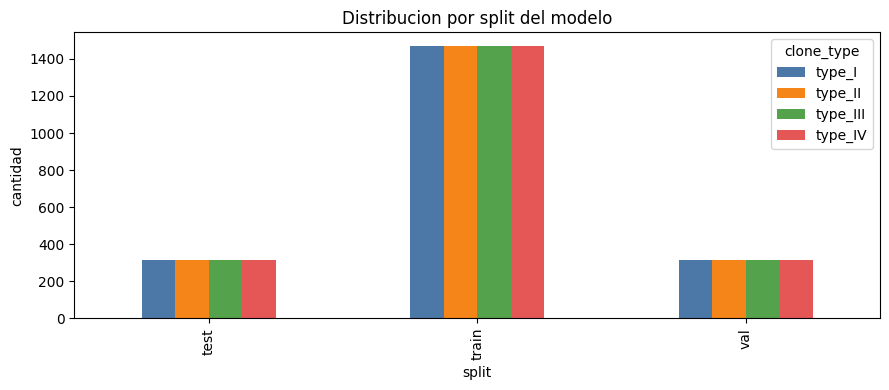

In [48]:
def split_por_grupo(df: pd.DataFrame, group_col: str, target_col: str, seed: int = 42, train_size: float = 0.7, val_size: float = 0.15, test_size: float = 0.15) -> ResultadoSplit:
    # Split en dos fases preservando grupos (problem_id)
    proporcion_temp = val_size + test_size
    proporcion_test_rel = test_size / proporcion_temp

    # 1) train vs temp
    gss_train = GroupShuffleSplit(n_splits=1, train_size=train_size, random_state=seed)
    idx_train_np, idx_temp_np = next(gss_train.split(df, y=df[target_col], groups=df[group_col]))

    # 2) val vs test dentro de temp
    df_temp = df.iloc[idx_temp_np]
    gss_temp = GroupShuffleSplit(n_splits=1, test_size=proporcion_test_rel, random_state=seed)
    idx_val_rel, idx_test_rel = next(gss_temp.split(df_temp, y=df_temp[target_col], groups=df_temp[group_col]))

    return ResultadoSplit(train_idx=df.index[idx_train_np], val_idx=df_temp.index[idx_val_rel], test_idx=df_temp.index[idx_test_rel])


def asignar_split(df, idx_train, idx_val, idx_test, nombre_columna='split'):
    # Etiqueta cada fila con su particion
    datos = df.copy()
    datos[nombre_columna] = 'unassigned'
    datos.loc[idx_train, nombre_columna] = 'train'
    datos.loc[idx_val, nombre_columna] = 'val'
    datos.loc[idx_test, nombre_columna] = 'test'
    return datos


def estadisticas_split(df: pd.DataFrame, split_col: str, target_col: str, group_col: str) -> list[dict[str, Any]]:
    # Resumen rapido para validar balance y cantidad de grupos por split
    resumen = []
    for nombre_split, df_split in df.groupby(split_col):
        conteos = df_split[target_col].value_counts().to_dict()
        resumen.append({'split': nombre_split, 'rows': int(len(df_split)), 'unique_groups': int(df_split[group_col].nunique()), 'class_distribution': {str(k): int(v) for k, v in conteos.items()}})
    return resumen


def balancear_train(df_train: pd.DataFrame, target_col: str, estrategia: str = 'none', seed: int = 42):
    # Balancea solo train para no contaminar val/test
    conteos = df_train[target_col].value_counts()
    info = {'strategy': estrategia, 'target_col': target_col, 'rows_before': int(len(df_train)), 'class_distribution_before': {str(k): int(v) for k, v in conteos.items()}}

    if estrategia == 'none' or len(conteos) <= 1:
        info['rows_after'] = int(len(df_train))
        info['class_distribution_after'] = info['class_distribution_before']
        return df_train.copy(), info

    if estrategia == 'undersample':
        n_obj = int(conteos.min())
        rep = False
    elif estrategia == 'oversample':
        n_obj = int(conteos.max())
        rep = True
    else:
        info['rows_after'] = int(len(df_train))
        info['class_distribution_after'] = info['class_distribution_before']
        return df_train.copy(), info

    partes = []
    for clase in conteos.index.tolist():
        df_clase = df_train[df_train[target_col] == clase]
        partes.append(df_clase.sample(n=n_obj, replace=rep, random_state=seed))

    out = pd.concat(partes, axis=0).sample(frac=1.0, random_state=seed).copy()
    c2 = out[target_col].value_counts()
    info['rows_after'] = int(len(out))
    info['class_distribution_after'] = {str(k): int(v) for k, v in c2.items()}
    return out, info


# Split principal del modelo
split_modelo = split_por_grupo(
    df=datos_preparados,
    group_col='problem_id',
    target_col='clone_type',
    seed=SEED + 100,
    train_size=0.7,
    val_size=0.15,
    test_size=0.15,
)

datos_modelo = asignar_split(datos_preparados, split_modelo.train_idx, split_modelo.val_idx, split_modelo.test_idx)

print('Estadisticas split del modelo:')
stats_modelo = estadisticas_split(datos_modelo, 'split', 'clone_type', 'problem_id')
for fila in stats_modelo:
    print(fila)

# Inspeccion visual de la distribucion de clases por split
conteos_split = datos_modelo.groupby(['split', 'clone_type']).size().unstack(fill_value=0)
conteos_split.plot(kind='bar', figsize=(9, 4), color=['#4C78A8', '#F58518', '#54A24B', '#E45756'])
plt.title('Distribucion por split del modelo')
plt.xlabel('split')
plt.ylabel('cantidad')
plt.tight_layout()
plt.show()


## 7) Entrenamiento y comparacion interna del modelo por capas


<unknown>:2: SyntaxWarning: invalid escape sequence '\]'
<unknown>:2: SyntaxWarning: invalid escape sequence '\]'
<unknown>:2: SyntaxWarning: invalid escape sequence '\]'
<unknown>:2: SyntaxWarning: invalid escape sequence '\]'
<unknown>:2: SyntaxWarning: invalid escape sequence '\]'
<unknown>:2: SyntaxWarning: invalid escape sequence '\]'
<unknown>:2: SyntaxWarning: invalid escape sequence '\]'
<unknown>:2: SyntaxWarning: invalid escape sequence '\]'
<unknown>:2: SyntaxWarning: invalid escape sequence '\]'
<unknown>:2: SyntaxWarning: invalid escape sequence '\]'
<unknown>:2: SyntaxWarning: invalid escape sequence '\]'
<unknown>:2: SyntaxWarning: invalid escape sequence '\]'
<unknown>:2: SyntaxWarning: invalid escape sequence '\]'
<unknown>:2: SyntaxWarning: invalid escape sequence '\]'
<unknown>:2: SyntaxWarning: invalid escape sequence '\]'
<unknown>:2: SyntaxWarning: invalid escape sequence '\]'
<unknown>:2: SyntaxWarning: invalid escape sequence '\]'
<unknown>:2: SyntaxWarning: inv

--- Balanceo train (misma estrategia) ---
{'strategy': 'undersample', 'target_col': 'clone_type', 'rows_before': 5880, 'class_distribution_before': {'type_I': 1470, 'type_II': 1470, 'type_III': 1470, 'type_IV': 1470}, 'rows_after': 5880, 'class_distribution_after': {'type_IV': 1470, 'type_III': 1470, 'type_I': 1470, 'type_II': 1470}}

num_features capa 1: 19
num_features capa 1 + capa 2 AST: 33

Metricas TEST capa 1 -> accuracy: 0.9024 f1_macro: 0.9023
Metricas TEST capa 1 + capa 2 AST -> accuracy: 0.8976 f1_macro: 0.8976


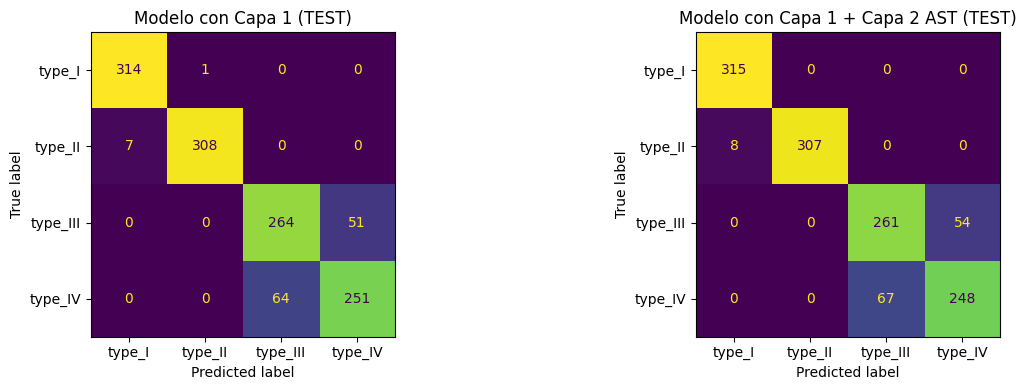

In [49]:
def evaluar_predicciones(y_true, y_pred, labels: list) -> dict[str, Any]:
    acc = accuracy_score(y_true, y_pred)
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    p_w, r_w, f1_w, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
    reporte_dict = classification_report(y_true, y_pred, labels=labels, output_dict=True, zero_division=0)
    reporte_texto = classification_report(y_true, y_pred, labels=labels, zero_division=0)
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    return {
        'accuracy': float(acc),
        'precision_macro': float(p_macro),
        'recall_macro': float(r_macro),
        'f1_macro': float(f1_macro),
        'precision_weighted': float(p_w),
        'recall_weighted': float(r_w),
        'f1_weighted': float(f1_w),
        'confusion_matrix': cm.tolist(),
        'classification_report_dict': reporte_dict,
        'classification_report_text': reporte_texto,
    }


def entrenar_evaluar_modelo(datos_task, columna_target, etiquetas, seed, estrategia_balanceo='none', min_match_len=3, usar_ast=False):
    train_raw = datos_task[datos_task['split'] == 'train'].copy()
    val = datos_task[datos_task['split'] == 'val'].copy()
    test = datos_task[datos_task['split'] == 'test'].copy()

    train_balanceado, info_balanceo = balancear_train(train_raw, columna_target, estrategia_balanceo, seed)

    vector_tfidf = ajustar_tfidf(train_balanceado)
    if usar_ast:
        X_train = construir_features_modelo_capa1_ast(train_balanceado, vector_tfidf, min_match_len=min_match_len)
        X_val = construir_features_modelo_capa1_ast(val, vector_tfidf, min_match_len=min_match_len)
        X_test = construir_features_modelo_capa1_ast(test, vector_tfidf, min_match_len=min_match_len)
    else:
        X_train = construir_features_modelo_capa1(train_balanceado, vector_tfidf, min_match_len=min_match_len)
        X_val = construir_features_modelo_capa1(val, vector_tfidf, min_match_len=min_match_len)
        X_test = construir_features_modelo_capa1(test, vector_tfidf, min_match_len=min_match_len)

    model = DecisionTreeClassifier(criterion='gini', max_depth=12, min_samples_leaf=2, class_weight='balanced', random_state=seed)
    model.fit(X_train, train_balanceado[columna_target])

    y_val = val[columna_target]
    y_test = test[columna_target]
    pred_val = model.predict(X_val)
    pred_test = model.predict(X_test)

    metricas_val = evaluar_predicciones(y_val, pred_val, labels=etiquetas)
    metricas_test = evaluar_predicciones(y_test, pred_test, labels=etiquetas)

    return {
        'info_balanceo': info_balanceo,
        'metricas_val': metricas_val,
        'metricas_test': metricas_test,
        'modelo': model,
        'num_features': int(X_train.shape[1]),
    }


def graficar_matrices_comparadas(res_capa1: dict, res_capa1_ast: dict, etiquetas: list[str]):
    cm_a = np.array(res_capa1['metricas_test']['confusion_matrix'])
    cm_b = np.array(res_capa1_ast['metricas_test']['confusion_matrix'])
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    ConfusionMatrixDisplay(cm_a, display_labels=[str(x) for x in etiquetas]).plot(ax=axes[0], colorbar=False)
    axes[0].set_title('Modelo con Capa 1 (TEST)')
    ConfusionMatrixDisplay(cm_b, display_labels=[str(x) for x in etiquetas]).plot(ax=axes[1], colorbar=False)
    axes[1].set_title('Modelo con Capa 1 + Capa 2 AST (TEST)')
    plt.tight_layout()
    plt.show()


etiquetas_modelo = sorted(datos_modelo['clone_type'].unique().tolist())

resultado_modelo_capa1 = entrenar_evaluar_modelo(
    datos_modelo,
    columna_target='clone_type',
    etiquetas=etiquetas_modelo,
    seed=SEED + 100,
    estrategia_balanceo=ESTRATEGIA_BALANCEO,
    min_match_len=MIN_MATCH_LEN_BAKER,
    usar_ast=False,
)

resultado_modelo_capa1_ast = entrenar_evaluar_modelo(
    datos_modelo,
    columna_target='clone_type',
    etiquetas=etiquetas_modelo,
    seed=SEED + 100,
    estrategia_balanceo=ESTRATEGIA_BALANCEO,
    min_match_len=MIN_MATCH_LEN_BAKER,
    usar_ast=True,
)

print('--- Balanceo train (misma estrategia) ---')
print(resultado_modelo_capa1['info_balanceo'])
print('')
print('num_features capa 1:', resultado_modelo_capa1['num_features'])
print('num_features capa 1 + capa 2 AST:', resultado_modelo_capa1_ast['num_features'])
print('')
print('Metricas TEST capa 1 -> accuracy:', round(resultado_modelo_capa1['metricas_test']['accuracy'], 4), 'f1_macro:', round(resultado_modelo_capa1['metricas_test']['f1_macro'], 4))
print('Metricas TEST capa 1 + capa 2 AST -> accuracy:', round(resultado_modelo_capa1_ast['metricas_test']['accuracy'], 4), 'f1_macro:', round(resultado_modelo_capa1_ast['metricas_test']['f1_macro'], 4))

graficar_matrices_comparadas(resultado_modelo_capa1, resultado_modelo_capa1_ast, etiquetas_modelo)


## 8) Evaluacion y reflexion del modelo (capa 1 vs capa 1 + capa 2)


In [50]:
resumen_modelo = pd.DataFrame([
    {
        'version_modelo': 'capa_1_lexica',
        'num_features': resultado_modelo_capa1['num_features'],
        'accuracy_val': resultado_modelo_capa1['metricas_val']['accuracy'],
        'f1_macro_val': resultado_modelo_capa1['metricas_val']['f1_macro'],
        'accuracy_test': resultado_modelo_capa1['metricas_test']['accuracy'],
        'f1_macro_test': resultado_modelo_capa1['metricas_test']['f1_macro'],
    },
    {
        'version_modelo': 'capa_1_lexica_mas_capa_2_ast',
        'num_features': resultado_modelo_capa1_ast['num_features'],
        'accuracy_val': resultado_modelo_capa1_ast['metricas_val']['accuracy'],
        'f1_macro_val': resultado_modelo_capa1_ast['metricas_val']['f1_macro'],
        'accuracy_test': resultado_modelo_capa1_ast['metricas_test']['accuracy'],
        'f1_macro_test': resultado_modelo_capa1_ast['metricas_test']['f1_macro'],
    },
])

print('Resumen comparativo del modelo por capas:')
display(resumen_modelo)

rep1 = resultado_modelo_capa1['metricas_test']['classification_report_dict']
rep2 = resultado_modelo_capa1_ast['metricas_test']['classification_report_dict']
rows_cls = []
for lbl in etiquetas_modelo:
    rows_cls.append({
        'label': lbl,
        'f1_capa1': rep1[lbl]['f1-score'],
        'f1_capa1_ast': rep2[lbl]['f1-score'],
        'delta_f1': rep2[lbl]['f1-score'] - rep1[lbl]['f1-score'],
        'recall_capa1': rep1[lbl]['recall'],
        'recall_capa1_ast': rep2[lbl]['recall'],
        'delta_recall': rep2[lbl]['recall'] - rep1[lbl]['recall'],
    })

df_por_clase = pd.DataFrame(rows_cls).sort_values('label')
print('Comparacion por clase (TEST):')
display(df_por_clase)

# reflexion automatica enfocada en type_III y type_IV
df_foco = df_por_clase[df_por_clase['label'].isin(['type_III', 'type_IV'])].copy()
prom_delta_f1 = float(df_foco['delta_f1'].mean())
prom_delta_recall = float(df_foco['delta_recall'].mean())

print('Reflexion (foco en type_III y type_IV):')
print(f'- Promedio delta F1: {prom_delta_f1:+.6f}')
print(f'- Promedio delta Recall: {prom_delta_recall:+.6f}')
if prom_delta_f1 > 0:
    print('- La capa 2 AST aporta mejora neta en clones complejos en esta corrida.')
elif prom_delta_f1 < 0:
    print('- La capa 2 AST no mejora en promedio clones complejos en esta corrida; conviene enriquecer rasgos AST.')
else:
    print('- El aporte de la capa 2 AST es neutro en esta corrida para clones complejos.')


Resumen comparativo del modelo por capas:


,version_modelo,num_features,accuracy_val,f1_macro_val,accuracy_test,f1_macro_test
0,capa_1_lexica,19,0.916667,0.916566,0.902381,0.902341
1,capa_1_lexica_mas_capa_2_ast,33,0.916667,0.916526,0.897619,0.897577


Comparacion por clase (TEST):


,label,f1_capa1,f1_capa1_ast,delta_f1,recall_capa1,recall_capa1_ast,delta_recall
0,type_I,0.987421,0.987461,0.000039,0.996825,1.000000,0.003175
1,type_II,0.987179,0.987138,-0.000041,0.977778,0.974603,-0.003175
2,type_III,0.821151,0.811820,-0.009331,0.838095,0.828571,-0.009524
3,type_IV,0.813614,0.803890,-0.009724,0.796825,0.787302,-0.009524


Reflexion (foco en type_III y type_IV):
- Promedio delta F1: -0.009528
- Promedio delta Recall: -0.009524
- La capa 2 AST no mejora en promedio clones complejos en esta corrida; conviene enriquecer rasgos AST.


## 9) Interpretacion de resultados

La comparacion anterior permite interpretar el impacto estructural de AST sobre la base lexica.

Puntos de lectura recomendados:
- Cambios globales en `accuracy_test` y `f1_macro_test`.
- Cambios por clase en `df_por_clase`.
- Comportamiento especifico en `type_III` y `type_IV` (clones mas complejos).


## 10) Siguiente paso del proyecto

Con capas 1 y 2 integradas, la siguiente iteracion agregara:

1. Capa de contexto
2. Capa de embeddings

La continuidad se mantiene por capas acumulativas sobre este modelo.
